In [1]:
#  Multi-Class Logistic Regression with One-vs-All Strategy for Iris Dataset Classification


Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

Logistic Regression

In [3]:
class logisticRegression:
    def __init__(self):
        #theta list to store updated weights
        self.theta=None
        self.lr=None
        #predictions list to store predictions so that after certain iterations loss can be calculated
        self.y_pred=None
        
    # Function to get recent weights(parameters)
    def Get_weights(self):
        return self.theta
    
    #function to return probability
    def sigmoid(self, z):
        #print(z)
        a=1 / (1 + np.exp(-z))
        return a
    
    
    # prediction function
    def hypothesis(self,X,theta):
        # making additional column of ones in X for (θ1*x1 +θ2*x2 + (θ0))
        X = np.column_stack((X, np.ones(X.shape[0])))
        # taking dot product while reshaping theta so that is is stacked vertically [](num of features in X x 1 ) 
        dot_product=np.dot(X,theta.reshape(-1,1))
        return self.sigmoid(dot_product)

    # Function for parameters update 
    def gradient_descent(self,theta,deriv_theta,alpha):
        # calculation new theta(parameters update)
        new_theta=theta - (alpha *deriv_theta)
        return new_theta
    
    # Loss Function
    def cost_function(self, y, y_pred):
        #length of y to get total samples count
        #print(y_pred)
        m = len(y)
        cost = (-1 / m)*np.sum(y*np.log(y_pred)+(1 - y)*np.log(1-y_pred))
        return cost
    
    # Function for Loss curve 
    def plot_trainingCurve(self,loss_array,loss_at_iteration):
        # plotting tarining curve, iterations on x-axis and loss on y-axis
        plt.plot(loss_at_iteration,loss_array, 'r-')
        plt.yscale("log")
        plt.title('Loss Curve')
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
        plt.show()

    #Training function
    def Train(self,X,y,alpha=0.01,max_iterations=-1,loss_iterations=10):
        # generating random thetas at start of shape, features of X with additional column for θ0 
        self.theta=np.random.uniform(low=-1, high=1, size=(X.shape[1]+1,1))
        
        self.lr=alpha
        # reshape y so that it has shape num_of_features x 1
        y= y.reshape(-1,1)
        # lists to store loss and iteration number for that loss , for plotting curve at end
        loss_array=np.array([])
        loss_at_iteration=np.array([])
        
        # case if num of iterations for training is not specified by user
        if max_iterations <= 0:
            old_loss=float('inf')
            max_iterations=7000
            # variable to keep record of , if the loss is not changing for certain number of iterations than stop training
            consecutive_negligible_changes = 0
            
            for iteration in range(max_iterations):
                # finding derivative 
                self.derivative_cost(X,y,self.theta)
                # condition for calculating loss (from cost function)
                if iteration % loss_iterations == 0:
                    # call cost function to find loss between actual and predicted
                    loss=self.cost_function(y,self.y_pred)
                    # store loss and iteration number for that loss , for plotting curve at end
                    loss_array=np.append(loss_array,loss)
                    loss_at_iteration=np.append(loss_at_iteration,iteration)
                    
                    print(f"Loss at iteration {iteration} is : {loss}")
                    #print(self.y_pred)
                    
                    # condition to check if the relative change in loss between the two iterations is small,
                    # loss must be less than 0.1% of the previous loss to be considered negligible.
                    if abs(old_loss - loss) < 0.001 * old_loss:
                        consecutive_negligible_changes =consecutive_negligible_changes+ 1
                        
                    # if consecutive 3 times it is not found negligible change than it is reset to 0
                    else:
                        consecutive_negligible_changes = 0
                        
                    # condition to check if the loss for consecutive 3 times is negligible than stop training
                    # it means that quality of model is not improving
                    if consecutive_negligible_changes ==3:
                        print("Consecutive negligible changes detected. Stopping training.")
                        break
                    old_loss = loss
            
        # condition if number of maximum iterations are specified
        else:
            for iteration in range(max_iterations):
                #calling function to find derivative of loss function
                self.derivative_cost(X,y,self.theta)
                
                if iteration % loss_iterations==0:
                    # call cost function to find loss between actual and predicted
                    loss=self.cost_function(y,self.y_pred)
                    # store loss and iteration number for that loss , for plotting curve at end
                    loss_array=np.append(loss_array,loss)
                    loss_at_iteration=np.append(loss_at_iteration,iteration)
                    
                    print(f"Loss at iteration {iteration} is : {loss} ")
                    #print(self.y_pred)
        # calling plotting function to plot training curve
        self.plot_trainingCurve(loss_array,loss_at_iteration)
    
    def derivative_cost(self,X,y,theta):
        array=[]
        # calculate hypothesis
        hypoth=self.hypothesis(X,theta)
        # store predictions
        self.y_pred=hypoth
        
        
        # perform (y - hypothesis)
        subtract_y_from_hypoth=self.y_pred -y
        
        # loop for (hypothesis)* xi :- multiplying predictions to there respective feature 
        # w.r.t θ1 :- (y-hypothesis)* x1 and so on
        
        for i in range(X.shape[1]):
            
            # reshape that feature to make it num_of features x 1
            temp_x=X[:,i].reshape(-1,1)
            multiplication=subtract_y_from_hypoth * temp_x
            # perform division by number of example
            # 1/num of samples * Σ (y-hypothesis)
            
            mean=np.mean(multiplication)
            # store the new parameters
            array.append(mean)
        
        # take derivative w.r.t θ0
        wrt_theta_not=np.mean(subtract_y_from_hypoth)
        array.append(wrt_theta_not)
        
        self.theta=np.array(array)
        self.theta=self.theta.reshape(-1,1)
        
        # call gradient descent function to update parameters (θ's)
        
        self.theta=self.gradient_descent(theta,self.theta,self.lr)
   

    # prediction function
    # inside it we call hyposthesis
    def Predict(self,X_test,weights):
        prob_y_pred=self.hypothesis(X_test,weights)
        #above threshold class 1 below class 0
        y_pred_class = (prob_y_pred >= 0.5)*1
        return y_pred_class
    
    #function to return the confidence of each test sample
    def predict_confidence(self, X_test,weights):
        return self.hypothesis(X_test,weights)

Helping functions

In [4]:

#function to find accuracy
def find_accuracy(orig_test,predictions):
    return  accuracy_score(orig_test, predictions)

#train test split
def Func_train_test_split(test_size=0.20, random_state=45):
    iris=pd.read_csv("IRIS.csv")
    X = np.array(iris.iloc[:,:-1])
    
    y = np.array(iris.iloc[:,-1])

    #train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state= random_state)

    return X_train, X_test, y_train, y_test

# function to modify labels according to model
def one_vs_ALL(target_class,label):
    #if the label equals the target class label than make it 1 else 0
    labels_new=[1 if i==target_class else 0 for i in label]
    return labels_new

# Calling train test split
X_train, X_test, y_train, y_test=Func_train_test_split()

#printing shapes of train and test data

print(f"Shape of X_train is:{X_train.shape} and Y_train is :{y_train.shape}")
print(f"Shape of X_test is:{X_test.shape} and Y_test is :{y_test.shape}")

# to store confidences from each model
# to store labels from each model
confidences=[]
labels=[]

Shape of X_train is:(120, 4) and Y_train is :(120,)
Shape of X_test is:(30, 4) and Y_test is :(30,)


Training model 1-Setosa

Loss at iteration 0 is : 8.126655682682799
Loss at iteration 100 is : 0.35581684883550696
Loss at iteration 200 is : 0.23314510944066746
Loss at iteration 300 is : 0.17126558994155128
Loss at iteration 400 is : 0.1350549233044046
Loss at iteration 500 is : 0.11152119233279686
Loss at iteration 600 is : 0.09506024596381649
Loss at iteration 700 is : 0.0829169323332641
Loss at iteration 800 is : 0.07359335489595456
Loss at iteration 900 is : 0.06620950386957546
Loss at iteration 1000 is : 0.06021592280683589
Loss at iteration 1100 is : 0.05525238159549637
Loss at iteration 1200 is : 0.05107309526697324
Loss at iteration 1300 is : 0.047504709816066776
Loss at iteration 1400 is : 0.04442148920426483
Loss at iteration 1500 is : 0.04173003048675698
Loss at iteration 1600 is : 0.0393595031433495
Loss at iteration 1700 is : 0.037255219225183586
Loss at iteration 1800 is : 0.03537428127189727
Loss at iteration 1900 is : 0.033682565506213964
Loss at iteration 2000 is : 0.0321525859824892
Loss at

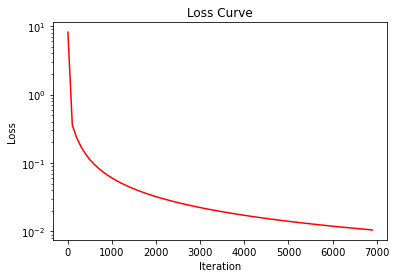


weights_setosa are 
 [[ 0.30849895]
 [ 2.03273491]
 [-2.52588356]
 [-1.0842467 ]
 [-0.13620911]]



In [5]:
#modifying labels for setosa 1 vs 0( 1 0 0 )
y_train_setosa=np.array(one_vs_ALL("Iris-setosa",y_train))
y_test_setosa=np.array(one_vs_ALL("Iris-setosa",y_test))

logistic_Obj_setosa=logisticRegression()


# Train
logistic_Obj_setosa.Train(X=X_train,y=y_train_setosa,alpha=0.01,loss_iterations=100)
weights_setosa=logistic_Obj_setosa.Get_weights()
print(f"\nweights_setosa are \n {weights_setosa}\n")

#prediction
prediction_setosa=logistic_Obj_setosa.Predict(X_test,weights_setosa)
confidence_setosa=logistic_Obj_setosa.predict_confidence(X_test,weights_setosa)

confidences.append(confidence_setosa)
labels.append(prediction_setosa)


Loss at iteration 0 is : 1.081254560650298
Loss at iteration 100 is : 0.9074191426188132
Loss at iteration 200 is : 0.8568383032636099
Loss at iteration 300 is : 0.8324435833332273
Loss at iteration 400 is : 0.8127035714556876
Loss at iteration 500 is : 0.7948827284676806
Loss at iteration 600 is : 0.7786230968513642
Loss at iteration 700 is : 0.763794514502063
Loss at iteration 800 is : 0.7502870515060269
Loss at iteration 900 is : 0.7379948390323557
Loss at iteration 1000 is : 0.7268160504082963
Loss at iteration 1100 is : 0.71665383214013
Loss at iteration 1200 is : 0.7074170015356666
Loss at iteration 1300 is : 0.699020465159715
Loss at iteration 1400 is : 0.6913854016031543
Loss at iteration 1500 is : 0.6844392573071494
Loss at iteration 1600 is : 0.6781156005923948
Loss at iteration 1700 is : 0.6723538733538048
Loss at iteration 1800 is : 0.6670990735216344
Loss at iteration 1900 is : 0.6623013950921806
Loss at iteration 2000 is : 0.6579158467259509
Loss at iteration 2100 is : 0.

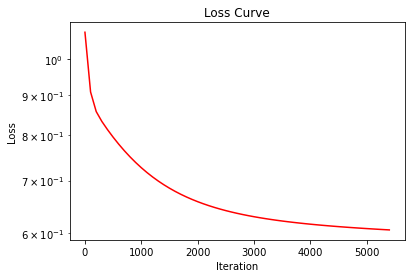


weights_versicolor are 
 [[-0.53884619]
 [ 0.08798483]
 [ 0.7020477 ]
 [-0.52515525]
 [ 0.22174658]]



In [6]:
#modifying labels for versicolor 1 vs 0( 0 1 0 )
y_train_versicolor=np.array(one_vs_ALL("Iris-versicolor",y_train))
y_test_versicolor=np.array(one_vs_ALL("Iris-versicolor",y_test))

logistic_Obj_versicolor=logisticRegression()


# Training
logistic_Obj_versicolor.Train(X=X_train,y=y_train_versicolor,alpha=0.001,loss_iterations=100)
weights_versicolor=logistic_Obj_versicolor.Get_weights()
print(f"\nweights_versicolor are \n {weights_versicolor}\n")

#prediction
prediction_versicolor=logistic_Obj_versicolor.Predict(X_test,weights_versicolor)
confidence_versicolor=logistic_Obj_versicolor.predict_confidence(X_test,weights_versicolor)

confidences.append(confidence_versicolor)
labels.append(prediction_versicolor)


Loss at iteration 0 is : 0.4749734384730194
Loss at iteration 200 is : 0.34740772843484097
Loss at iteration 400 is : 0.3150729007311473
Loss at iteration 600 is : 0.2932345799005411
Loss at iteration 800 is : 0.27669195587567547
Loss at iteration 1000 is : 0.26332515081149116
Loss at iteration 1200 is : 0.25208580413035675
Loss at iteration 1400 is : 0.24238309002314615
Loss at iteration 1600 is : 0.23385106311868542
Loss at iteration 1800 is : 0.22624632228075955
Loss at iteration 2000 is : 0.21939776980487188
Loss at iteration 2200 is : 0.21317976300060534
Loss at iteration 2400 is : 0.20749675773239334
Loss at iteration 2600 is : 0.20227401870760917
Loss at iteration 2800 is : 0.19745172784393444
Loss at iteration 3000 is : 0.19298109334640146
Loss at iteration 3200 is : 0.18882168836686256
Loss at iteration 3400 is : 0.18493957413967368
Loss at iteration 3600 is : 0.18130594041662423
Loss at iteration 3800 is : 0.1778960971884505
Loss at iteration 4000 is : 0.1746887113074648
Loss

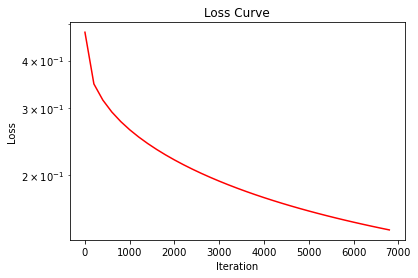


weights_virginica are 
 [[-2.28314851]
 [-1.07329756]
 [ 2.87822686]
 [ 2.40882958]
 [-0.82407902]]



In [7]:
#modifying labels for verginica 1 vs 0( 0 0 1 )
y_train_virginica=np.array(one_vs_ALL("Iris-virginica",y_train))
y_test_virginica=np.array(one_vs_ALL("Iris-virginica",y_test))


logistic_Obj_virginica=logisticRegression()


# Training
logistic_Obj_virginica.Train(X=X_train,y=y_train_virginica,alpha=0.01,loss_iterations=200)
weights_virginica=logistic_Obj_virginica.Get_weights()
print(f"\nweights_virginica are \n {weights_virginica}\n")

#prediction
prediction_virginica=logistic_Obj_virginica.Predict(X_test,weights_virginica)
confidence_virginica=logistic_Obj_virginica.predict_confidence(X_test,weights_virginica)

confidences.append(confidence_virginica)
labels.append(prediction_virginica)


Accuracy For each model

In [8]:
    
#accuracy for each model
accuracy_1 =find_accuracy(y_test_setosa, prediction_setosa)
accuracy_2 =find_accuracy(y_test_versicolor, prediction_versicolor)
accuracy_3 =find_accuracy(y_test_virginica,prediction_virginica)

print(f"Model 1-Setosa have accuracy 1 vs all: {accuracy_1 }")
print(f"Model 2-versicolor have accuracy 1 vs all: {accuracy_2 }")
print(f"Model 3-verginica have accuracy 1 vs all: {accuracy_3 }")


Model 1-Setosa have accuracy 1 vs all: 1.0
Model 2-versicolor have accuracy 1 vs all: 0.7333333333333333
Model 3-verginica have accuracy 1 vs all: 0.9666666666666667


Find labels based on max probabilities

In [9]:
# Initialize an empty list to store the indices of the maximum probabilities -labels
max_labels = []

#looping through each sample
for p1, p2, p3 in zip(confidences[0], confidences[1],confidences[2]):
    max_prob = max(p1[0], p2[0], p3[0])  #maximum probability
    # Compare each probability to find the which model is giving the maximum confidence
    if max_prob == p1[0]:
        #means 1st list from setosa model is giving max confidence
        max_index = 0
        max_labels.append(max_index)
    elif max_prob == p2[0]:
        #means 2nd list from versicolor model is giving max confidence
        max_index = 1
        max_labels.append(max_index)
    else:
        #means 3rd list from virginica model is giving max confidence
        max_index = 2
        max_labels.append(max_index)
        
#changing original test labels to integers
y_test_orig= np.empty_like(y_test, dtype=int)
y_test_orig[y_test == "Iris-setosa"] = 0
y_test_orig[y_test == "Iris-versicolor"] = 1
y_test_orig[y_test == "Iris-virginica"] = 2

Final accuracy

In [10]:
accuracy= find_accuracy(y_test_orig, max_labels)
print("Final performance for all classes:\n",classification_report(y_test_orig, max_labels))
print("\n",accuracy)

Final performance for all classes:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.86      0.92         7
           2       0.92      1.00      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30


 0.9666666666666667
